ПАПКА С ДАННЫМИ:
F:\University\Методы анализа данных\2 Семестр\Пр2\3.08

ЧИСЛО ЗАПУСКОВ: 128
АЛГОРИТМЫ: ['allnet10', 'dijkstraqueue']
ИЗВЕСТНЫЕ QUANTITY: [np.int64(100), np.int64(300), np.int64(500), np.int64(700), np.int64(900), np.int64(1000), np.int64(1300), np.int64(1500)]
НОВЫЕ QUANTITY: [200, 800, 1100]
СПОСОБ ВОССТАНОВЛЕНИЯ: линейная интерполяция по quantity


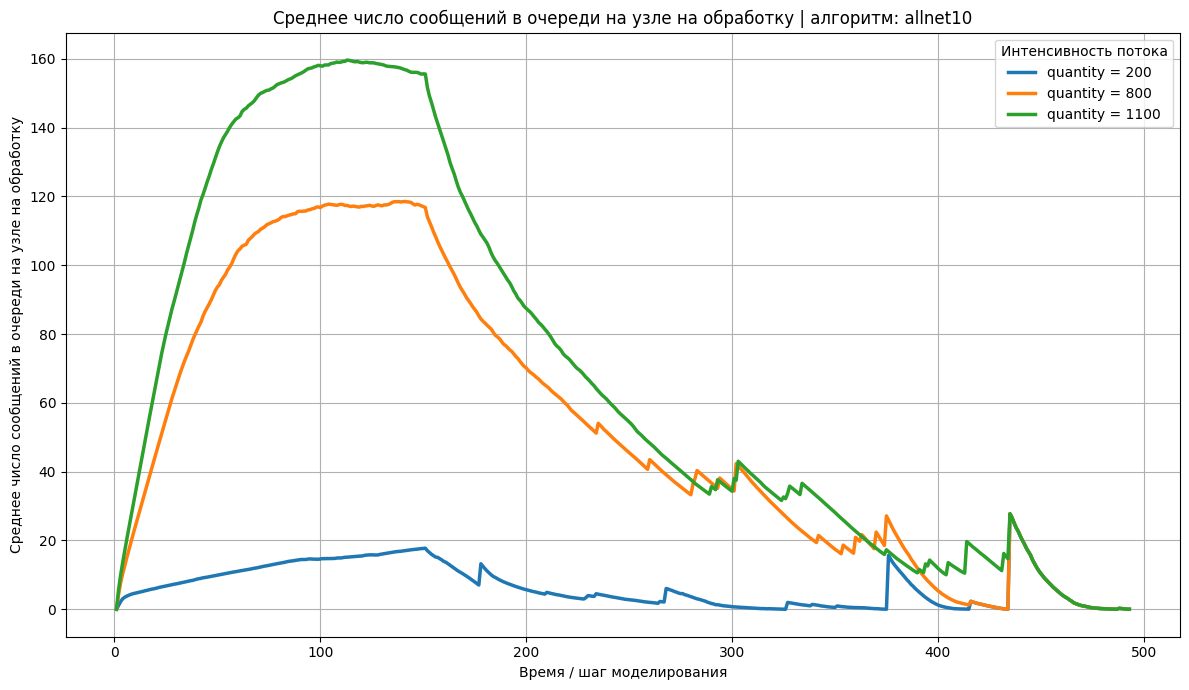

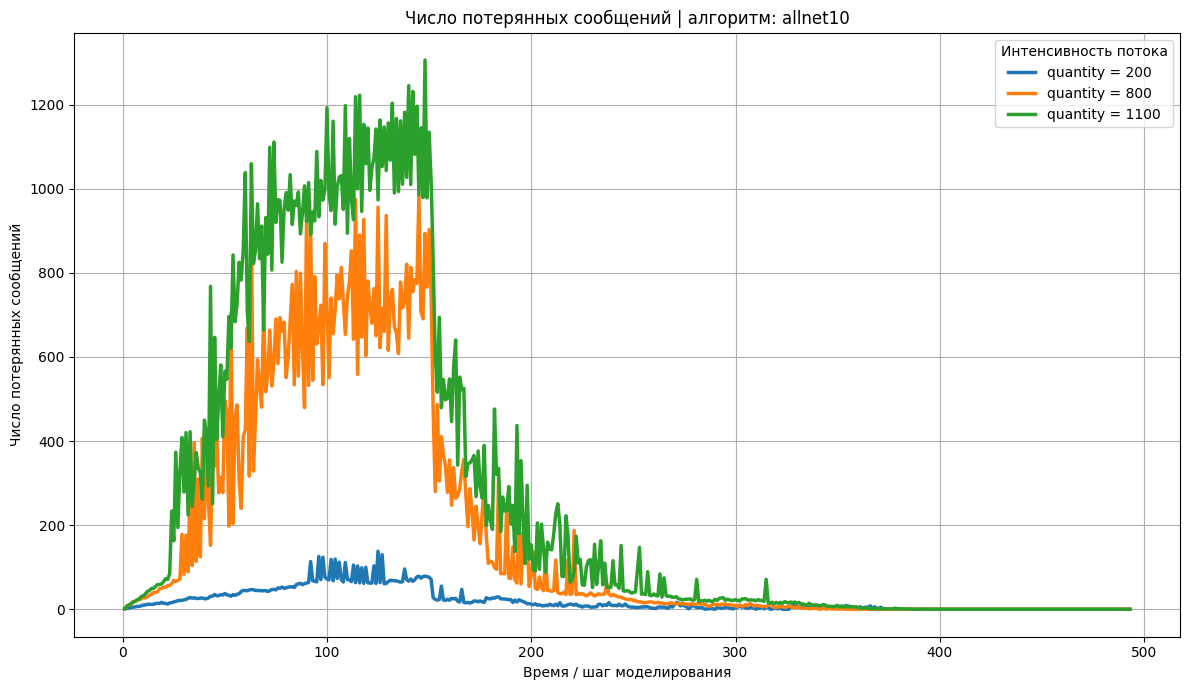

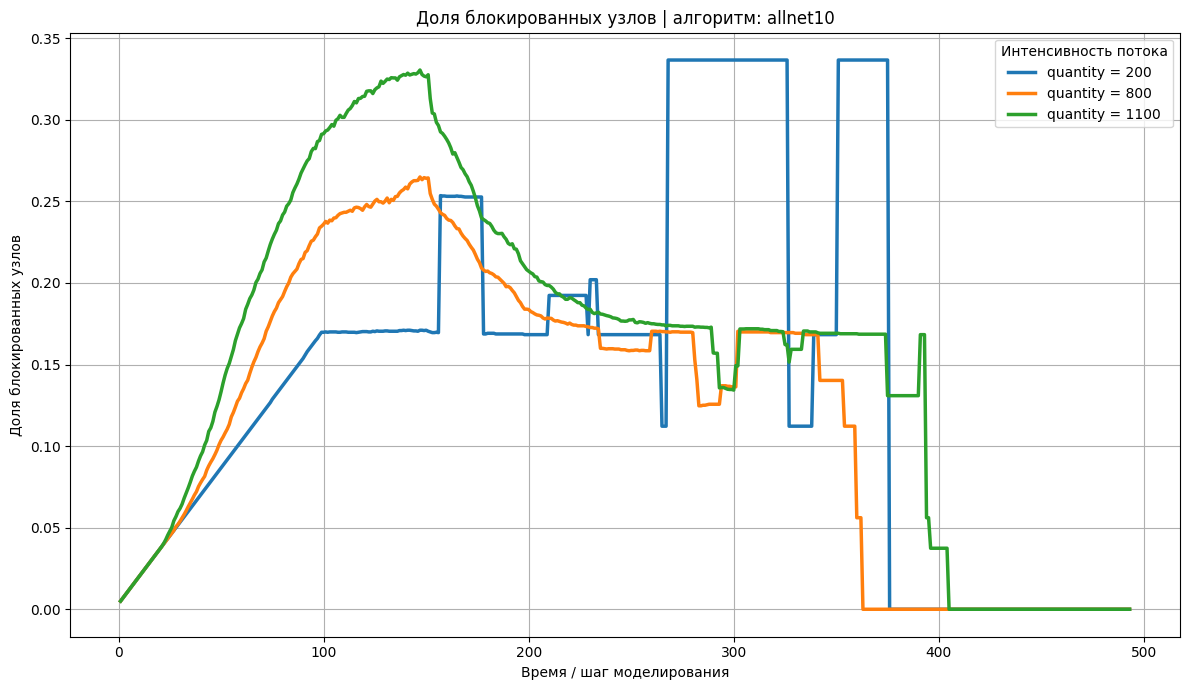

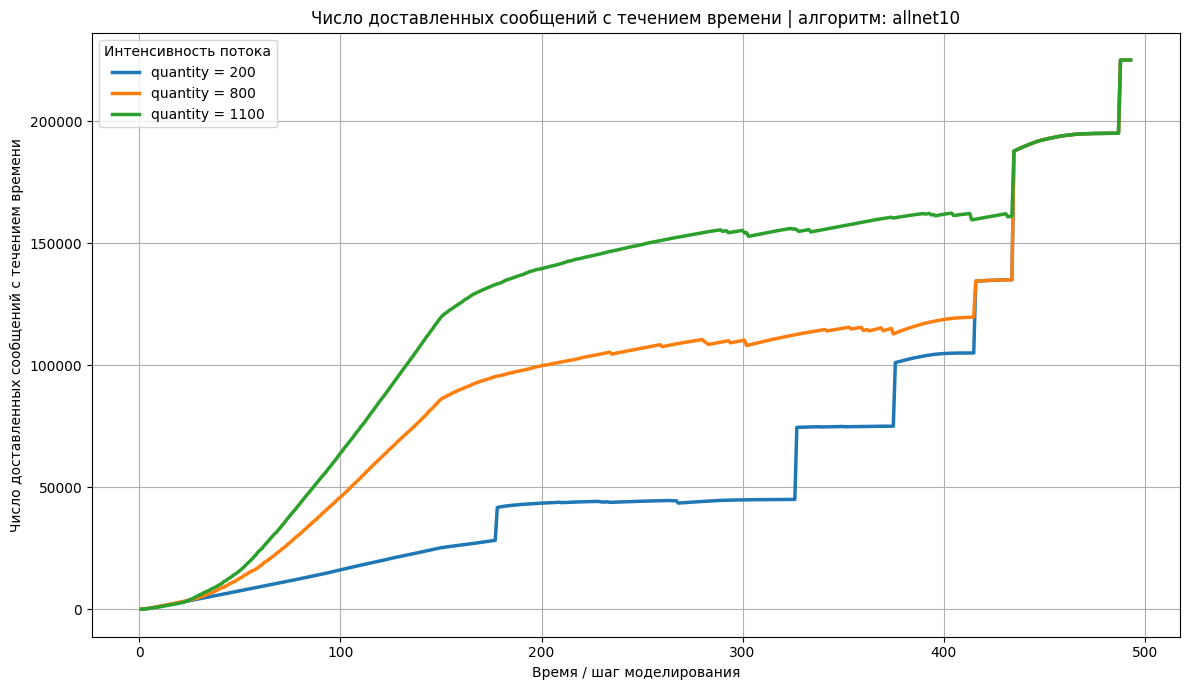

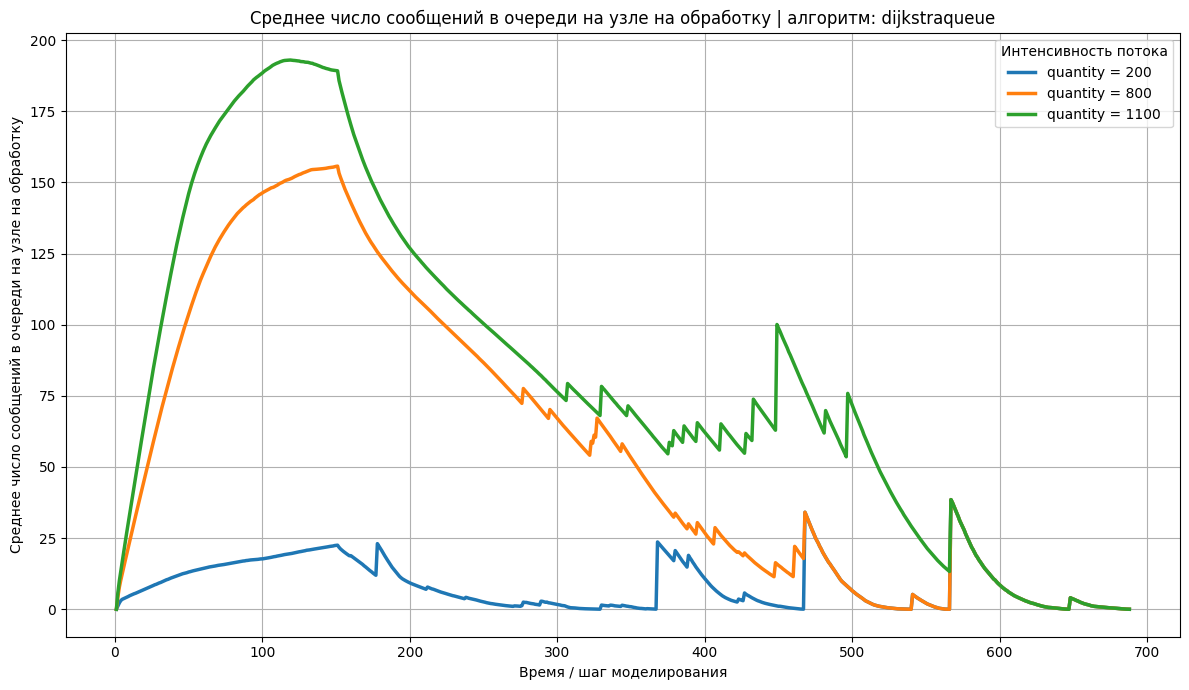

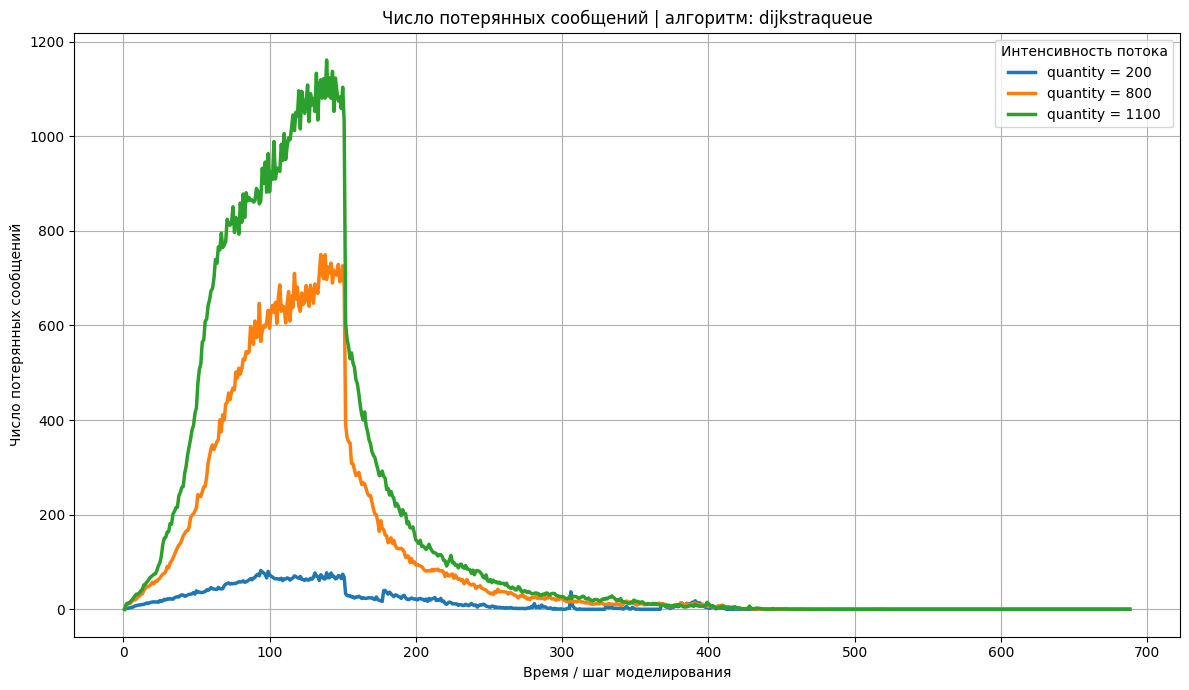

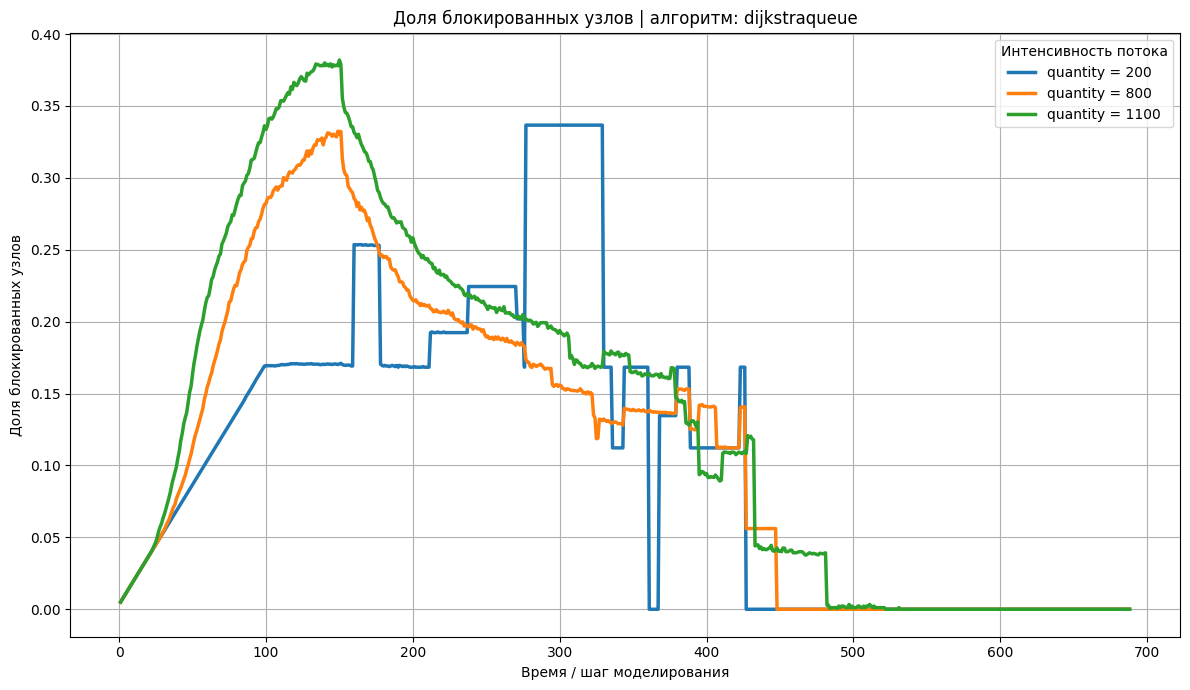

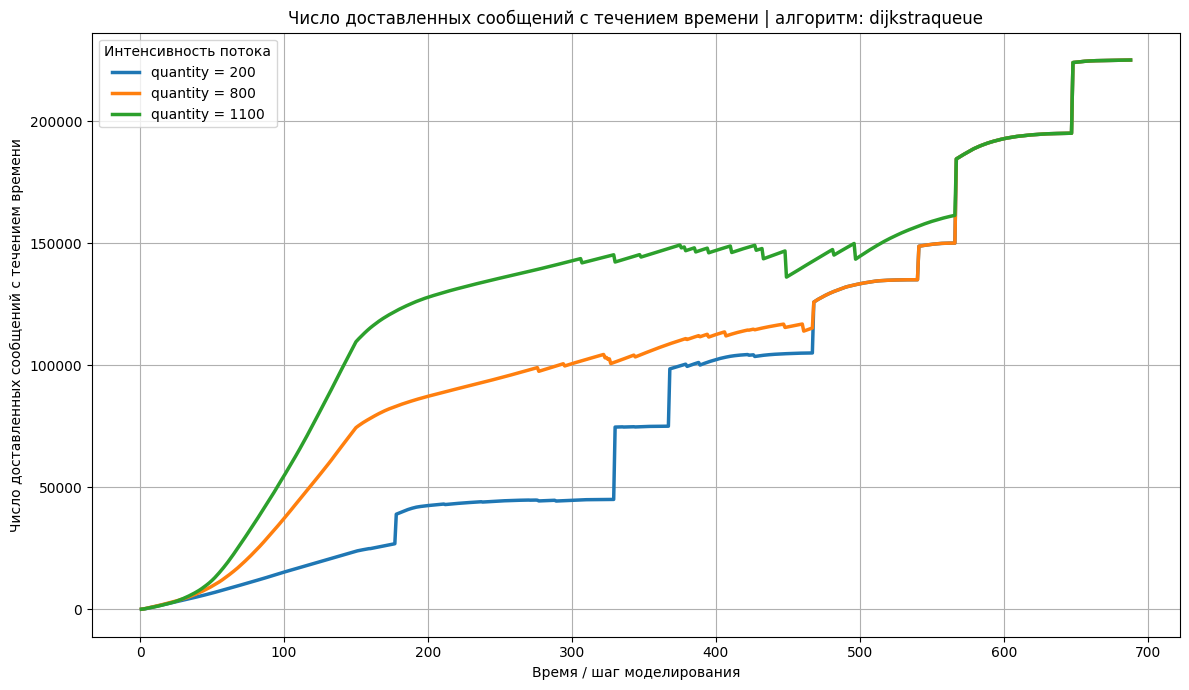

In [5]:
import os
import re
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# ============================================================================
# НАСТРОЙКИ
# ============================================================================
# Код подходит для двух вариантов:
# 1) запуск как обычный .py файл
# 2) запуск внутри Jupyter Notebook
#
# Предполагается, что код запускается из корня распакованного архива
# или рядом с папкой "3.08".
# ============================================================================

TARGET_QUANTITIES = [200, 800, 1100]
NODE_COUNT = 300
DATA_FOLDER_NAME = "3.08"

METRIC_TITLES = {
    "avg_node_queue": "Среднее число сообщений в очереди на узле на обработку",
    "failed_messages": "Число потерянных сообщений",
    "blocked_fraction": "Доля блокированных узлов",
    "delivered_cumulative": "Число доставленных сообщений с течением времени",
}


# ============================================================================
# ПОИСК ПАПКИ С ДАННЫМИ
# ============================================================================


def running_in_notebook():
    """
    Возвращает True, если код запущен в Jupyter Notebook.
    """
    try:
        from IPython import get_ipython

        shell = get_ipython()
        if shell is None:
            return False

        return shell.__class__.__name__ == "ZMQInteractiveShell"
    except Exception:
        return False



def get_base_dirs():
    """
    Возвращает список каталогов, где имеет смысл искать папку 3.08.
    """
    base_dirs = []

    current_dir = os.getcwd()
    if os.path.isdir(current_dir):
        base_dirs.append(current_dir)

    if not running_in_notebook():
        try:
            script_dir = os.path.dirname(os.path.abspath(__file__))
            if os.path.isdir(script_dir) and script_dir not in base_dirs:
                base_dirs.append(script_dir)
        except Exception:
            pass

    return base_dirs



def find_data_dir():
    """
    Ищет папку 3.08 автоматически.
    """
    base_dirs = get_base_dirs()

    for base_dir in base_dirs:
        candidate = os.path.join(base_dir, DATA_FOLDER_NAME)
        if os.path.isdir(candidate):
            return candidate

    for base_dir in base_dirs:
        for root, dirs, _ in os.walk(base_dir):
            if DATA_FOLDER_NAME in dirs:
                return os.path.join(root, DATA_FOLDER_NAME)

    raise ValueError(
        "Не удалось найти папку '3.08'. "
        "Для Jupyter Notebook запустите notebook из корня распакованного архива "
        "или перейдите в нужную папку через os.chdir(...)."
    )


# ============================================================================
# ЧТЕНИЕ ИСХОДНЫХ ДАННЫХ
# ============================================================================


def parse_logs(data_dir):
    """
    Из логов строит таблицу:
    tag -> algorithm, quantity
    """
    rows = []
    log_names = ["logs20220807.txt", "logs20220813.txt"]

    for log_name in log_names:
        log_path = os.path.join(data_dir, log_name)
        if not os.path.exists(log_path):
            continue

        current_algorithm = None
        current_quantity = None

        with open(log_path, "r", encoding="utf-8", errors="replace") as file:
            for line in file:
                if "RoutingAlgorithm" in line:
                    match = re.search(r"RoutingAlgorithm\s+([A-Za-z0-9_]+)", line)
                    if match:
                        current_algorithm = match.group(1)

                elif "Quantity" in line:
                    match = re.search(r"Quantity\s+(\d+)", line)
                    if match:
                        current_quantity = int(match.group(1))

                elif re.search(r"\[INF\]\s+[0-9a-f\-]{36}", line):
                    match = re.search(r"([0-9a-f\-]{36})", line)
                    if match:
                        rows.append(
                            {
                                "tag": match.group(1),
                                "algorithm": current_algorithm,
                                "quantity": current_quantity,
                            }
                        )

    result = pd.DataFrame(rows).drop_duplicates().reset_index(drop=True)

    if result.empty:
        raise ValueError("Не удалось прочитать параметры экспериментов из логов.")

    return result



def read_mean_over_nodes(file_path):
    """
    Для файлов вида Netsim-Node-Metrics-queue-{tag}.
    Каждая строка содержит значения по узлам.
    Возвращает среднее значение по узлам на каждом шаге.
    """
    series = []

    with open(file_path, "r", encoding="utf-8", errors="replace") as file:
        for line in file:
            line = line.strip()
            if not line:
                continue

            numbers = [int(x) for x in line.split(",") if x != ""]
            series.append(float(np.mean(numbers)))

    return np.array(series, dtype=float)



def read_blocked_fraction(file_path):
    """
    Для файлов вида Netsim-Node-Metrics-blocked-{tag}.
    В строке значения 0/1 по узлам.
    Возвращает долю заблокированных узлов на каждом шаге.
    """
    series = []

    with open(file_path, "r", encoding="utf-8", errors="replace") as file:
        for line in file:
            line = line.strip()
            if not line:
                continue

            numbers = [int(x) for x in line.split(",") if x != ""]
            series.append(sum(numbers) / NODE_COUNT)

    return np.array(series, dtype=float)



def read_scalar_series(file_path):
    """
    Для файлов вида Netsim-Message-Metrics-failed-{tag}.
    В каждой строке одно число.
    """
    series = []

    with open(file_path, "r", encoding="utf-8", errors="replace") as file:
        for line in file:
            line = line.strip()
            if not line:
                continue

            series.append(float(line.replace(",", ".")))

    return np.array(series, dtype=float)



def read_delivered_cumulative(file_path, total_steps):
    """
    Для файла Netsim-Message-Metrics-{tag}.

    В конце каждой строки есть timestamp.
    Считаем число доставленных сообщений на каждом шаге,
    затем строим накопленную сумму.
    """
    time_format = "%d.%m.%Y %H:%M:%S"
    delivered_per_second = {}

    with open(file_path, "r", encoding="utf-8", errors="replace") as file:
        for line in file:
            line = line.strip()
            if not line:
                continue

            parts = line.split(",")
            timestamp_text = parts[-1].strip()

            moment = datetime.strptime(timestamp_text, time_format)
            simulation_start = moment.replace(hour=1, minute=0, second=0)

            second_number = int((moment - simulation_start).total_seconds())
            delivered_per_second[second_number] = delivered_per_second.get(second_number, 0) + 1

    per_step = np.zeros(total_steps, dtype=float)

    for second_number in range(1, total_steps + 1):
        per_step[second_number - 1] = delivered_per_second.get(second_number, 0)

    return np.cumsum(per_step)



def load_runs(data_dir, experiments):
    """
    Читает все нужные метрики для всех запусков.
    Возвращает длинную таблицу:
    algorithm, quantity, tag, step, metric, value
    """
    rows = []

    for _, experiment in experiments.iterrows():
        tag = experiment["tag"]
        algorithm = experiment["algorithm"]
        quantity = experiment["quantity"]

        queue_path = os.path.join(data_dir, f"Netsim-Node-Metrics-queue-{tag}")
        failed_path = os.path.join(data_dir, f"Netsim-Message-Metrics-failed-{tag}")
        blocked_path = os.path.join(data_dir, f"Netsim-Node-Metrics-blocked-{tag}")
        delivered_path = os.path.join(data_dir, f"Netsim-Message-Metrics-{tag}")

        required_files = [queue_path, failed_path, blocked_path, delivered_path]
        if not all(os.path.exists(path) for path in required_files):
            continue

        avg_node_queue = read_mean_over_nodes(queue_path)
        failed_messages = read_scalar_series(failed_path)
        blocked_fraction = read_blocked_fraction(blocked_path)

        total_steps = min(len(avg_node_queue), len(failed_messages), len(blocked_fraction))
        delivered_cumulative = read_delivered_cumulative(delivered_path, total_steps)

        metrics = {
            "avg_node_queue": avg_node_queue[:total_steps],
            "failed_messages": failed_messages[:total_steps],
            "blocked_fraction": blocked_fraction[:total_steps],
            "delivered_cumulative": delivered_cumulative[:total_steps],
        }

        for metric_name, values in metrics.items():
            for step_index, value in enumerate(values, start=1):
                rows.append(
                    {
                        "algorithm": algorithm,
                        "quantity": quantity,
                        "tag": tag,
                        "step": step_index,
                        "metric": metric_name,
                        "value": float(value),
                    }
                )

    result = pd.DataFrame(rows)

    if result.empty:
        raise ValueError(
            "Не удалось собрать таблицу метрик. "
            "Проверьте, что в папке 3.08 есть файлы Netsim-..."
        )

    return result


# ============================================================================
# ВОССТАНОВЛЕНИЕ ПРОМЕЖУТОЧНЫХ QUANTITY
# ============================================================================


def build_mean_curves(data):
    """
    Усредняет реальные кривые по повторам.
    """
    result = (
        data.groupby(["algorithm", "quantity", "step", "metric"], as_index=False)["value"]
        .mean()
        .copy()
    )
    result["source"] = "observed_mean"
    return result



def interpolate_value(known_quantities, known_values, target_quantity):
    """
    Восстанавливает значение для промежуточного quantity.

    Используется обычная линейная интерполяция по quantity.
    Это устойчивый и понятный способ для данной задачи,
    потому что все целевые quantity находятся внутри диапазона
    известных значений: 200, 800 и 1100.
    """
    quantities_array = np.array(known_quantities, dtype=float)
    values_array = np.array(known_values, dtype=float)

    sort_index = np.argsort(quantities_array)
    quantities_array = quantities_array[sort_index]
    values_array = values_array[sort_index]

    unique_quantities = []
    unique_values = []

    for quantity in np.unique(quantities_array):
        mask = quantities_array == quantity
        unique_quantities.append(float(quantity))
        unique_values.append(float(np.mean(values_array[mask])))

    return float(np.interp(target_quantity, unique_quantities, unique_values))



def predict_missing_quantities(observed_means, target_quantities):
    """
    Для каждого algorithm, metric и step восстанавливает значения
    для quantity = 200, 800, 1100.

    В отличие от полиномиальной регрессии, линейная интерполяция:
    - не вызывает предупреждений Singular matrix;
    - не вызывает предупреждений Ill-conditioned matrix;
    - хорошо подходит именно для промежуточных точек.
    """
    rows = []
    grouped = observed_means.groupby(["algorithm", "metric", "step"])

    for (algorithm, metric_name, step), group in grouped:
        known_quantities = group["quantity"].to_list()
        known_values = group["value"].to_list()

        for target_quantity in target_quantities:
            predicted_value = interpolate_value(
                known_quantities,
                known_values,
                target_quantity,
            )

            rows.append(
                {
                    "algorithm": algorithm,
                    "quantity": target_quantity,
                    "step": step,
                    "metric": metric_name,
                    "value": predicted_value,
                    "source": "predicted",
                }
            )

    return pd.DataFrame(rows)


# ============================================================================
# ВЫВОД РЕЗУЛЬТАТОВ
# ============================================================================


def print_summary(experiments, data_dir):
    print("=" * 80)
    print("ПАПКА С ДАННЫМИ:")
    print(data_dir)
    print()
    print("ЧИСЛО ЗАПУСКОВ:", len(experiments))
    print("АЛГОРИТМЫ:", sorted(experiments["algorithm"].dropna().unique()))
    print("ИЗВЕСТНЫЕ QUANTITY:", sorted(experiments["quantity"].dropna().unique()))
    print("НОВЫЕ QUANTITY:", TARGET_QUANTITIES)
    print("СПОСОБ ВОССТАНОВЛЕНИЯ: линейная интерполяция по quantity")
    print("=" * 80)



def plot_one_metric(predictions, algorithm, metric_name):
    """
    Строит один график только для quantity 200, 800, 1100.
    """
    predicted_part = predictions[
        (predictions["algorithm"] == algorithm)
        & (predictions["metric"] == metric_name)
    ]

    plt.figure(figsize=(12, 7))

    for quantity in TARGET_QUANTITIES:
        curve = predicted_part[predicted_part["quantity"] == quantity].sort_values("step")
        if curve.empty:
            continue

        plt.plot(
            curve["step"],
            curve["value"],
            linewidth=2.5,
            label=f"quantity = {quantity}",
        )

    plt.title(f"{METRIC_TITLES[metric_name]} | алгоритм: {algorithm}")
    plt.xlabel("Время / шаг моделирования")
    plt.ylabel(METRIC_TITLES[metric_name])
    plt.grid(True)
    plt.legend(title="Интенсивность потока")
    plt.tight_layout()
    plt.show()



def plot_all(predictions):
    """
    Показывает только графики, которые требуются в задании.
    """
    algorithms = sorted(predictions["algorithm"].unique())
    metrics = [
        "avg_node_queue",
        "failed_messages",
        "blocked_fraction",
        "delivered_cumulative",
    ]

    for algorithm in algorithms:
        for metric_name in metrics:
            plot_one_metric(predictions, algorithm, metric_name)


# ============================================================================
# MAIN
# ============================================================================


def main():
    data_dir = find_data_dir()
    experiments = parse_logs(data_dir)
    data = load_runs(data_dir, experiments)

    observed_means = build_mean_curves(data)
    predictions = predict_missing_quantities(observed_means, TARGET_QUANTITIES)

    print_summary(experiments, data_dir)
    plot_all(predictions)

    return observed_means, predictions


if __name__ == "__main__":
    main()
